# Optional Lab: 使用 Scikit-Learn 进行线性回归

有一个名为[scikit-learn](https://scikit-learn.org/stable/index.html)的开源、可商业使用的机器学习工具包。这个工具包包含了你在本课程中将会使用的许多算法的实现。



## 目标
在本实验中，你将：
- 利用 scikit-learn 通过梯度下降实现线性回归。

## 工具
你将使用来自 scikit-learn 的函数以及 matplotlib 和 NumPy。

In [1]:
import numpy as np
np.set_printoptions(precision=2)
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler
from lab_utils_multi import  load_house_data
import matplotlib.pyplot as plt
dlblue = '#0096ff'; dlorange = '#FF9300'; dldarkred='#C00000'; dlmagenta='#FF40FF'; dlpurple='#7030A0'; 
plt.style.use('./deeplearning.mplstyle')

# 梯度下降
Scikit-learn 有一个梯度下降回归模型[sklearn.linear_model.SGDRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html#examples-using-sklearn-linear-model-sgdregressor)。与你之前实现的梯度下降一样，这个模型在输入标准化的情况下表现最佳。
[sclearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html#sklearn.preprocessing.StandardScaler)（标准缩放器）将像在之前的实验中一样执行 z-score 标准化。在这里，它被称为“标准分数”。

### 加载数据集

In [2]:
X_train, y_train = load_house_data()
X_features = ['size(sqft)','bedrooms','floors','age']

### 缩放/归一化训练数据

In [3]:
scaler = StandardScaler()
X_norm = scaler.fit_transform(X_train)
print(f"Peak to Peak range by column in Raw        X:{np.ptp(X_train,axis=0)}")   
print(f"Peak to Peak range by column in Normalized X:{np.ptp(X_norm,axis=0)}")

Peak to Peak range by column in Raw        X:[2.41e+03 4.00e+00 1.00e+00 9.50e+01]
Peak to Peak range by column in Normalized X:[5.85 6.14 2.06 3.69]


### 创建并拟合回归模型

In [4]:
sgdr = SGDRegressor(max_iter=1000)
sgdr.fit(X_norm, y_train)
print(sgdr)
print(f"number of iterations completed: {sgdr.n_iter_}, number of weight updates: {sgdr.t_}")

SGDRegressor()
number of iterations completed: 136, number of weight updates: 13465.0


### 查看参数
注意，这些参数与*标准化*输入数据相关。拟合参数与上一个实验中用此数据找到的参数非常接近。

In [5]:
b_norm = sgdr.intercept_
w_norm = sgdr.coef_
print(f"model parameters:                   w: {w_norm}, b:{b_norm}")
print(f"model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16")

model parameters:                   w: [110.27 -21.13 -32.55 -38.  ], b:[363.16]
model parameters from previous lab: w: [110.56 -21.27 -32.71 -37.97], b: 363.16


### 进行预测
预测训练数据的目标。同时使用`predict`例程，并使用$w$和$b$进行计算。

In [6]:
# make a prediction using sgdr.predict()
y_pred_sgd = sgdr.predict(X_norm)
# make a prediction using w,b. 
y_pred = np.dot(X_norm, w_norm) + b_norm  
print(f"prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

print(f"Prediction on training set:\n{y_pred[:4]}" )
print(f"Target values \n{y_train[:4]}")

prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[295.21 485.9  389.57 492.06]
Target values 
[300.  509.8 394.  540. ]


### 绘制结果
让我们绘制预测值与目标值的对比图。

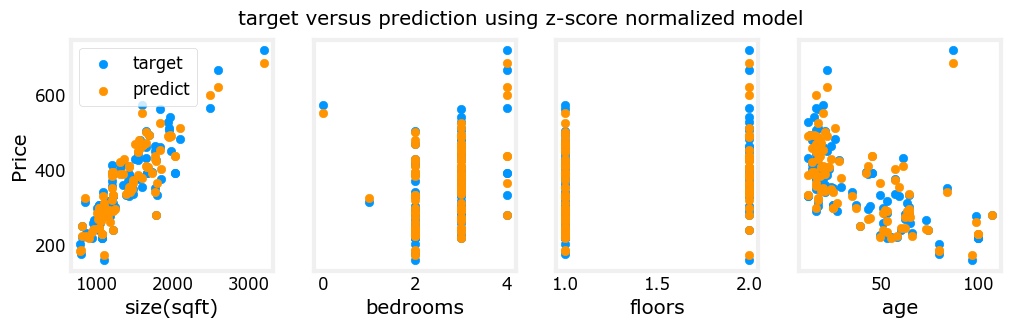

In [7]:
# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,4,figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(X_train[:,i],y_train, label = 'target')
    ax[i].set_xlabel(X_features[i])
    ax[i].scatter(X_train[:,i],y_pred,color=dlorange, label = 'predict')
ax[0].set_ylabel("Price"); ax[0].legend();
fig.suptitle("target versus prediction using z-score normalized model")
plt.show()

## 恭喜！
在这个实验中，你：
- 使用了一个开源机器学习工具包 scikit-learn。
- 利用该工具包中的梯度下降和特征归一化实现了线性回归。